# Learning reservoir dynamics from random interaction

This notebook uses the active Torch rollout implementation to collect random one-step transitions and trains a supervised neural network to predict the full next state from the current state and action.

## 1. Setup

In [36]:
import random
import sys
import warnings
from io import BytesIO
from pathlib import Path
from pprint import pprint

import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import numpy as np
import pyRDDLGym
import torch
from IPython.display import Image, display
from torch import nn

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "StochasticPBBP" / "core" / "Rollout.py").is_file():
    REPO_ROOT = Path("/Users/yuvalaroosh/StochasticPBBP")
if not (REPO_ROOT / "StochasticPBBP" / "core" / "Rollout.py").is_file():
    raise FileNotFoundError("Could not locate the StochasticPBBP repository root.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from StochasticPBBP.core.Logic import ExactLogic
from StochasticPBBP.core.Rollout import TorchRolloutCell

domain_path = REPO_ROOT / "StochasticPBBP" / "problems" / "reservoir" / "domain.rddl"
instance_path = REPO_ROOT / "StochasticPBBP" / "problems" / "reservoir" / "instance_3.rddl"

# Gymnasium warns that the RDDL bounds are cast to float32 inside its Box space.
warnings.filterwarnings("ignore", message=r".*Box (low|high)'s precision lowered.*")
env = pyRDDLGym.make(
    domain=str(domain_path),
    instance=str(instance_path),
    vectorized=True,
)
env.action_space.seed(SEED)

rddl_model = env.model
rollout_generator = torch.Generator().manual_seed(SEED)
rollout_cell = TorchRolloutCell(
    rddl_model,
    key=rollout_generator,
    logic=ExactLogic(),
)
initial_subs, _, _ = rollout_cell.reset()

STATE_KEYS = tuple(rddl_model.state_fluents.keys())
ACTION_KEYS = tuple(rollout_cell.noop_actions.keys())
HORIZON = int(rddl_model.horizon)

print("State fluent names:", list(STATE_KEYS))
print("Action fluent names:", list(ACTION_KEYS))
print("Horizon:", HORIZON)
print("State template shapes/dtypes:")
for name in STATE_KEYS:
    value = initial_subs[name]
    print(f"  {name}: shape={tuple(value.shape)}, dtype={value.dtype}")
print("Action template shapes/dtypes:")
for name in ACTION_KEYS:
    value = rollout_cell.noop_actions[name]
    print(f"  {name}: shape={tuple(value.shape)}, dtype={value.dtype}")

State fluent names: ['rlevel']
Action fluent names: ['release']
Horizon: 20
State template shapes/dtypes:
  rlevel: shape=(10,), dtype=torch.float64
Action template shapes/dtypes:
  release: shape=(10,), dtype=torch.float64


## 2. Full-state extraction helpers

In [37]:
def clone_tensor_dict(values, *, detach=False):
    """Clone a flat dictionary of tensor-like values without sharing storage."""
    cloned = {}
    for name, value in values.items():
        tensor = value if isinstance(value, torch.Tensor) else torch.as_tensor(value)
        if detach:
            tensor = tensor.detach()
        cloned[name] = tensor.clone()
    return cloned


def extract_state_dict(subs):
    """Return all state fluents in fixed order, coerced to their template tensors."""
    missing = [name for name in STATE_KEYS if name not in subs]
    if missing:
        raise KeyError(f"Missing state fluents in substitutions: {missing}")

    state = {}
    for name in STATE_KEYS:
        reference = initial_subs[name]
        reference = (
            reference if isinstance(reference, torch.Tensor) else torch.as_tensor(reference)
        )
        value = subs[name] if isinstance(subs[name], torch.Tensor) else torch.as_tensor(subs[name])
        if tuple(value.shape) != tuple(reference.shape):
            raise ValueError(
                f"State <{name}> must have shape {tuple(reference.shape)}, "
                f"got {tuple(value.shape)}."
            )
        state[name] = value.to(dtype=reference.dtype, device=reference.device).clone()
    return state


initial_state = extract_state_dict(initial_subs)
state_template = clone_tensor_dict(initial_state)
action_template = clone_tensor_dict(rollout_cell.noop_actions)

assert tuple(initial_state.keys()) == STATE_KEYS
assert tuple(action_template.keys()) == ACTION_KEYS

## 3. Random lifted policy

In [38]:
fallback_action_generator = torch.Generator().manual_seed(SEED + 1)


def _coerce_action_like_template(value, template, name):
    tensor = value if isinstance(value, torch.Tensor) else torch.as_tensor(value)
    tensor = tensor.to(device=template.device)
    if tuple(tensor.shape) != tuple(template.shape):
        raise ValueError(
            f"Action <{name}> must have shape {tuple(template.shape)}, "
            f"got {tuple(tensor.shape)}."
        )
    if template.dtype == torch.bool:
        return tensor.bool()
    return tensor.to(dtype=template.dtype)


def _sample_from_action_template(template):
    if template.dtype == torch.bool:
        sample = torch.randint(0, 2, template.shape, generator=fallback_action_generator)
        return sample.to(dtype=torch.bool, device=template.device)
    if template.dtype.is_floating_point:
        sample = torch.rand(
            template.shape,
            generator=fallback_action_generator,
            dtype=torch.float64,
        )
        return sample.to(dtype=template.dtype, device=template.device)
    sample = torch.randint(0, 2, template.shape, generator=fallback_action_generator)
    return sample.to(dtype=template.dtype, device=template.device)


def random_policy(current_state):
    """Sample a genuinely random lifted action with the canonical noop template."""
    missing = [name for name in STATE_KEYS if name not in current_state]
    if missing:
        raise KeyError(f"Policy received an incomplete state: {missing}")

    sampled_action = env.action_space.sample()
    actions = clone_tensor_dict(rollout_cell.noop_actions)
    for name in ACTION_KEYS:
        template = rollout_cell.noop_actions[name]
        if isinstance(sampled_action, dict) and name in sampled_action:
            actions[name] = _coerce_action_like_template(
                sampled_action[name], template, name
            )
        else:
            actions[name] = _sample_from_action_template(template)
    return rollout_cell.prepare_actions(actions)

## 4. One-step simulator

In [39]:
def simulate_next_state(state_dict, action_dict, *, return_done=False):
    """Simulate one transition from an explicit full state and lifted action."""
    current_state = clone_tensor_dict(
        {name: state_dict[name] for name in STATE_KEYS},
        detach=True,
    )
    safe_actions = clone_tensor_dict(action_dict, detach=True)

    subs, _, model_params = rollout_cell.reset(initial_state=current_state)
    next_subs, _, _, done, _ = rollout_cell.step(
        subs=subs,
        actions=safe_actions,
        model_params=model_params,
    )
    next_state = extract_state_dict(next_subs)
    if return_done:
        return next_state, bool(done)
    return next_state

## 5. Deterministic vectorization

In [40]:
MODEL_DTYPE = torch.float32
MODEL_DEVICE = torch.device("cpu")


def _build_tensor_specs(template, keys):
    specs = {}
    for name in keys:
        tensor = template[name]
        specs[name] = {
            "shape": tuple(tensor.shape),
            "numel": int(tensor.numel()),
            "dtype": tensor.dtype,
            "device": tensor.device,
        }
    return specs


STATE_SPECS = _build_tensor_specs(state_template, STATE_KEYS)
ACTION_SPECS = _build_tensor_specs(action_template, ACTION_KEYS)
STATE_DIM = sum(STATE_SPECS[name]["numel"] for name in STATE_KEYS)
ACTION_DIM = sum(ACTION_SPECS[name]["numel"] for name in ACTION_KEYS)


def _flatten_tensor_dict(values, specs, keys):
    parts = []
    for name in keys:
        if name not in values:
            raise KeyError(f"Missing tensor <{name}> during flattening.")
        value = values[name]
        tensor = value if isinstance(value, torch.Tensor) else torch.as_tensor(value)
        expected_shape = specs[name]["shape"]
        if tuple(tensor.shape) != expected_shape:
            raise ValueError(
                f"Tensor <{name}> must have shape {expected_shape}, "
                f"got {tuple(tensor.shape)}."
            )
        parts.append(tensor.to(device=MODEL_DEVICE, dtype=MODEL_DTYPE).reshape(-1))
    return torch.cat(parts, dim=0)


def flatten_state(state_dict):
    return _flatten_tensor_dict(state_dict, STATE_SPECS, STATE_KEYS)


def flatten_action(action_dict):
    return _flatten_tensor_dict(action_dict, ACTION_SPECS, ACTION_KEYS)


def unflatten_state_vector(state_vector):
    if state_vector.ndim != 1:
        raise ValueError(f"Expected a 1-D state vector, got shape {tuple(state_vector.shape)}.")
    if state_vector.numel() != STATE_DIM:
        raise ValueError(
            f"Expected {STATE_DIM} state values, got {state_vector.numel()}."
        )

    state_dict = {}
    start = 0
    for name in STATE_KEYS:
        spec = STATE_SPECS[name]
        end = start + spec["numel"]
        value = state_vector[start:end].reshape(spec["shape"])
        if spec["dtype"] == torch.bool:
            value = (value >= 0.5).to(device=spec["device"])
        elif spec["dtype"].is_floating_point:
            value = value.to(dtype=spec["dtype"], device=spec["device"])
        else:
            value = value.round().to(dtype=spec["dtype"], device=spec["device"])
        state_dict[name] = value
        start = end
    return state_dict


def unflatten_action_vector(action_vector):
    if action_vector.ndim != 1:
        raise ValueError(f"Expected a 1-D action vector, got shape {tuple(action_vector.shape)}.")
    if action_vector.numel() != ACTION_DIM:
        raise ValueError(
            f"Expected {ACTION_DIM} action values, got {action_vector.numel()}."
        )

    action_dict = {}
    start = 0
    for name in ACTION_KEYS:
        spec = ACTION_SPECS[name]
        end = start + spec["numel"]
        value = action_vector[start:end].reshape(spec["shape"])
        if spec["dtype"] == torch.bool:
            value = (value >= 0.5).to(device=spec["device"])
        elif spec["dtype"].is_floating_point:
            value = value.to(dtype=spec["dtype"], device=spec["device"])
        else:
            value = value.round().to(dtype=spec["dtype"], device=spec["device"])
        action_dict[name] = value
        start = end
    return action_dict


print(f"Flattened state dimension: {STATE_DIM}")
print(f"Flattened action dimension: {ACTION_DIM}")

Flattened state dimension: 10
Flattened action dimension: 10


## 6. Neural dynamics model

In [41]:
class DynamicsMLP(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim),
        )

    def forward(self, state_vector, action_vector):
        features = torch.cat((state_vector, action_vector), dim=-1)
        return self.network(features)


dynamics_model = DynamicsMLP(STATE_DIM, ACTION_DIM).to(MODEL_DEVICE)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(dynamics_model.parameters(), lr=1e-3)

print(dynamics_model)

DynamicsMLP(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 7. Random-interaction dataset generation and online training

In [42]:
TRAINING_ITERATIONS = 20000

loss_history = []
current_state = clone_tensor_dict(initial_state, detach=True)
episode_step = 0
first_transition = None

dynamics_model.train()
for iteration in range(1, TRAINING_ITERATIONS + 1):
    action = random_policy(current_state)
    true_next_state, done = simulate_next_state(
        current_state,
        action,
        return_done=True,
    )

    state_vector = flatten_state(current_state)
    action_vector = flatten_action(action)
    target_vector = flatten_state(true_next_state)

    predicted_vector = dynamics_model(state_vector, action_vector)
    loss = loss_function(predicted_vector, target_vector)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.detach()))
    if first_transition is None:
        first_transition = {
            "state": clone_tensor_dict(current_state, detach=True),
            "action": clone_tensor_dict(action, detach=True),
            "true_next_state": clone_tensor_dict(true_next_state, detach=True),
        }

    current_state = clone_tensor_dict(true_next_state, detach=True)
    episode_step += 1
    if done or episode_step >= HORIZON:
        current_state = clone_tensor_dict(initial_state, detach=True)
        episode_step = 0

    if iteration % 500 == 0:
        recent_mean = float(np.mean(loss_history[-100:]))
        print(f"Iteration {iteration:4d} | mean loss over last 100 steps: {recent_mean:.4f}")

dynamics_model.eval()
with torch.no_grad():
    first_prediction_vector = dynamics_model(
        flatten_state(first_transition["state"]),
        flatten_action(first_transition["action"]),
    )
first_predicted_next_state = unflatten_state_vector(first_prediction_vector)

Iteration  500 | mean loss over last 100 steps: 348.8768
Iteration 1000 | mean loss over last 100 steps: 250.5247
Iteration 1500 | mean loss over last 100 steps: 196.4213
Iteration 2000 | mean loss over last 100 steps: 203.6662
Iteration 2500 | mean loss over last 100 steps: 96.0260
Iteration 3000 | mean loss over last 100 steps: 197.6971
Iteration 3500 | mean loss over last 100 steps: 103.2029
Iteration 4000 | mean loss over last 100 steps: 154.6772
Iteration 4500 | mean loss over last 100 steps: 200.4123
Iteration 5000 | mean loss over last 100 steps: 96.2729
Iteration 5500 | mean loss over last 100 steps: 125.1181
Iteration 6000 | mean loss over last 100 steps: 194.8313
Iteration 6500 | mean loss over last 100 steps: 95.4020
Iteration 7000 | mean loss over last 100 steps: 76.9462
Iteration 7500 | mean loss over last 100 steps: 89.1876
Iteration 8000 | mean loss over last 100 steps: 74.9357
Iteration 8500 | mean loss over last 100 steps: 58.8149
Iteration 9000 | mean loss over last 1

## 8. Results

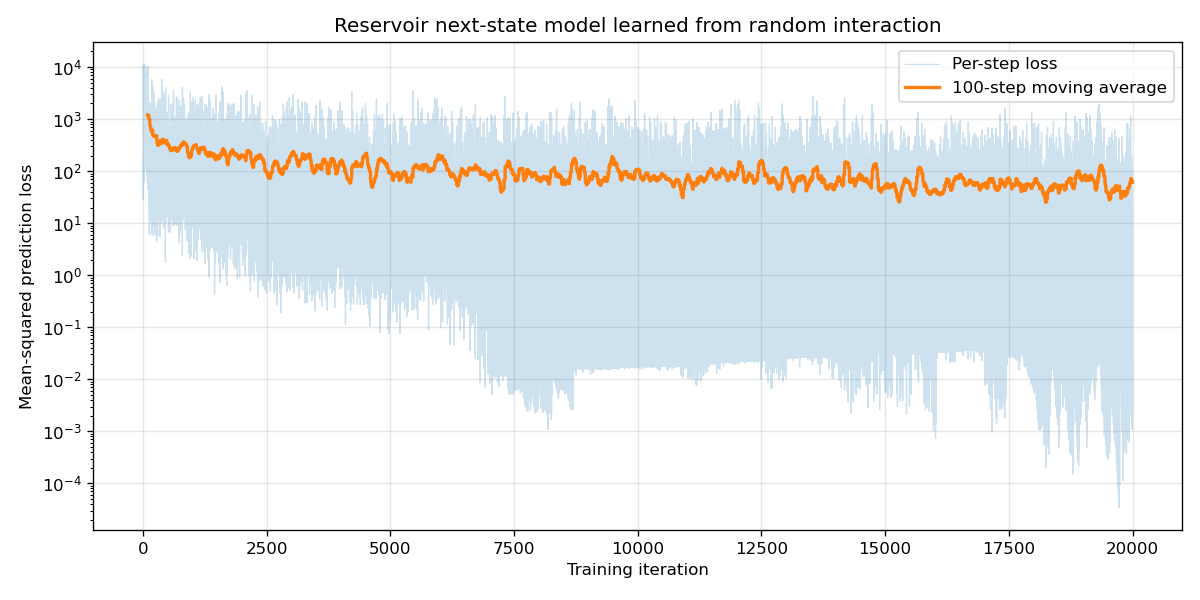

Initial 100-step mean loss: 1209.2936
Final 100-step mean loss:   61.6679

First collected transition after training:

Current state:
{'rlevel': [174.2944,
            287.6886,
            103.865,
            181.7504,
            125.0444,
            14.6739,
            103.2298,
            39.5758,
            118.2779,
            85.0989]}

Chosen action:
{'release': [95.094,
             263.7311,
             97.2335,
             178.1201,
             177.5011,
             17.8766,
             98.3912,
             82.7254,
             136.6612,
             2.6228]}

True next state:
{'rlevel': [79.2004,
            55.6555,
            137.0843,
            124.9167,
            94.4797,
            0.0,
            128.0497,
            23.6556,
            0.0,
            124.3238]}

Neural-network predicted next state:
{'rlevel': [91.7241,
            29.0798,
            136.1696,
            115.3344,
            89.5142,
            -0.1897,
            121.264

In [43]:
loss_array = np.asarray(loss_history, dtype=np.float64)
iteration_axis = np.arange(1, TRAINING_ITERATIONS + 1)
moving_average_window = 100
moving_average = np.convolve(
    loss_array,
    np.ones(moving_average_window) / moving_average_window,
    mode="valid",
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(iteration_axis, loss_array, alpha=0.22, linewidth=0.8, label="Per-step loss")
ax.plot(
    np.arange(moving_average_window, TRAINING_ITERATIONS + 1),
    moving_average,
    linewidth=2.0,
    label=f"{moving_average_window}-step moving average",
)
ax.set_xlabel("Training iteration")
ax.set_ylabel("Mean-squared prediction loss")
ax.set_title("Reservoir next-state model learned from random interaction")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plot_buffer = BytesIO()
fig.savefig(plot_buffer, format="png", dpi=120)
plt.close(fig)
display(Image(data=plot_buffer.getvalue()))


def readable_tensor_dict(values, digits=4):
    readable = {}
    for name, value in values.items():
        array = value.detach().cpu().numpy()
        if np.issubdtype(array.dtype, np.floating):
            array = array.astype(np.float64, copy=False)
        rounded = np.round(array, digits)
        readable[name] = rounded.item() if rounded.ndim == 0 else rounded.tolist()
    return readable


print(f"Initial 100-step mean loss: {loss_array[:100].mean():.4f}")
print(f"Final 100-step mean loss:   {loss_array[-100:].mean():.4f}")
print("\nFirst collected transition after training:\n")
for label, values in (
    ("Current state", first_transition["state"]),
    ("Chosen action", first_transition["action"]),
    ("True next state", first_transition["true_next_state"]),
    ("Neural-network predicted next state", first_predicted_next_state),
):
    print(f"{label}:")
    pprint(readable_tensor_dict(values), sort_dicts=False)
    print()

In [44]:
def _dict_spaces(space):
    spaces = getattr(space, "spaces", None)
    return spaces if isinstance(spaces, dict) else {}


def _to_bound_tensor(raw_bound, *, shape):
    tensor = torch.as_tensor(raw_bound, dtype=MODEL_DTYPE, device=MODEL_DEVICE)
    if tensor.numel() == 1:
        tensor = tensor.expand(shape)
    else:
        tensor = tensor.reshape(shape)
    return tensor


def build_state_bounds():
    observation_spaces = _dict_spaces(env.observation_space)
    bounds = {}

    for name in STATE_KEYS:
        spec = STATE_SPECS[name]
        lower = None
        upper = None

        if name in observation_spaces:
            state_space = observation_spaces[name]
            low = getattr(state_space, "low", None)
            high = getattr(state_space, "high", None)

            if low is not None:
                lower = _to_bound_tensor(low, shape=spec["shape"])
            if high is not None:
                upper = _to_bound_tensor(high, shape=spec["shape"])

        if rddl_model.variable_ranges[name] == "bool":
            if lower is None:
                lower = torch.zeros(spec["shape"], dtype=MODEL_DTYPE, device=MODEL_DEVICE)
            if upper is None:
                upper = torch.ones(spec["shape"], dtype=MODEL_DTYPE, device=MODEL_DEVICE)

        bounds[name] = {
            "min": lower,
            "max": upper,
        }

    return bounds


STATE_BOUNDS = build_state_bounds()


def clamp_state_vector_to_domain(state_vector):
    if state_vector.ndim != 1:
        raise ValueError(f"Expected a 1-D state vector, got shape {tuple(state_vector.shape)}.")

    projected_parts = []
    start = 0

    for name in STATE_KEYS:
        spec = STATE_SPECS[name]
        end = start + spec["numel"]

        piece = state_vector[start:end].reshape(spec["shape"])
        lower = STATE_BOUNDS[name]["min"]
        upper = STATE_BOUNDS[name]["max"]

        if lower is not None:
            piece = torch.maximum(piece, lower.to(device=piece.device, dtype=piece.dtype))
        if upper is not None:
            piece = torch.minimum(piece, upper.to(device=piece.device, dtype=piece.dtype))

        projected_parts.append(piece.reshape(-1))
        start = end

    return torch.cat(projected_parts, dim=0)

In [45]:
#
state_vector = torch.tensor(
    [15.4202, 13.2999 , 0.0, 0.0,11    ,12   ,  32, 12  ,14 ,12 ],
    dtype=MODEL_DTYPE,
    device=MODEL_DEVICE,
)
#
action_vector = torch.tensor(
    [13.4202, 123.2999 , 4.0, 5.0,1    ,55   ,  2, 2  ,44 ,52 ],
    dtype=MODEL_DTYPE,
    device=MODEL_DEVICE,
)

with torch.no_grad():
    model_input = torch.cat([state_vector, action_vector])
    predicted_vector = clamp_state_vector_to_domain(
        dynamics_model(state_vector, action_vector)
    )
    predicted_state = unflatten_state_vector(predicted_vector)

print("Predicted next-state vector:", predicted_vector)
print("Predicted next-state dictionary:", predicted_state)

print("State vector:", state_vector)
print("Action vector:", action_vector)
print("Combined NN input:", model_input)
print("Predicted next-state vector:", predicted_vector)
print("Predicted next-state dictionary:", predicted_state)
print("################################################")

the_real_next_state = simulate_next_state(
    unflatten_state_vector(state_vector),
    unflatten_action_vector(action_vector),
    return_done=False,)
print("The real next-state dictionary:", the_real_next_state)
diff = readable_tensor_dict(
    {name: predicted_state[name] - the_real_next_state[name] for name in STATE_KEYS}
)
print("Difference between predicted and real next-state:",diff)
total_abs_diff = sum(
    abs(value)
    for values in diff.values()
    for value in values
)
print("Total absolute difference:", total_abs_diff / 10)


Predicted next-state vector: tensor([ 9.2294,  0.0000,  8.9591,  4.8594,  9.0043,  0.3199, 13.1969,  1.0271,
         0.5383,  5.2087])
Predicted next-state dictionary: {'rlevel': tensor([ 9.2294,  0.0000,  8.9591,  4.8594,  9.0043,  0.3199, 13.1969,  1.0271,
         0.5383,  5.2087], dtype=torch.float64)}
State vector: tensor([15.4202, 13.2999,  0.0000,  0.0000, 11.0000, 12.0000, 32.0000, 12.0000,
        14.0000, 12.0000])
Action vector: tensor([ 13.4202, 123.2999,   4.0000,   5.0000,   1.0000,  55.0000,   2.0000,
          2.0000,  44.0000,  52.0000])
Combined NN input: tensor([ 15.4202,  13.2999,   0.0000,   0.0000,  11.0000,  12.0000,  32.0000,
         12.0000,  14.0000,  12.0000,  13.4202, 123.2999,   4.0000,   5.0000,
          1.0000,  55.0000,   2.0000,   2.0000,  44.0000,  52.0000])
Predicted next-state vector: tensor([ 9.2294,  0.0000,  8.9591,  4.8594,  9.0043,  0.3199, 13.1969,  1.0271,
         0.5383,  5.2087])
Predicted next-state dictionary: {'rlevel': tensor([ 9.229